In [1]:
import sys
sys.path.append("../scripts")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import binned_statistic, binned_statistic_2d
import multiprocessing as mp

In [3]:
import niceplots
niceplots.initPlot()

import seaborn as sns
Cs = sns.color_palette("colorblind")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
Cp = sns.color_palette("Paired")
Cp

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

# Obtain k modes

In [5]:
from specs import *
from meer21cm import PowerSpectrum

ps = PowerSpectrum(
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    nu=nu_arr,
    ra_range=ra_range,
    dec_range=dec_range,
    # downscale the resolution along line-of-sight
    downres_factor_radial = 6,
    # downscale the resolution on the transverse plane
    downres_factor_transverse = 3,
    omega_hi = 5e-4,
    tracer_bias_1 = 1.5,
    tracer_bias_2 = 1.5,
    mean_amp_1 = 'average_hi_temp',
    sigma_v_1=5,
    sigma_v_2=5,
)

ps.get_enclosing_box()

In [6]:
kmode3d = ps.k_mode
kx, ky, kz = ps.k_vec

kmask_simple = ~np.logical_or(
    kx[:, None, None]==0, np.logical_or(
        ky[:, None]==0, kz==0
    )
)
print(f"fraction of maked pixels {(~kmask_simple).astype(np.float64).mean()}")

fraction of maked pixels 0.1270338856545753


In [7]:
Nk = 25
kbins = np.geomspace(
    np.min(kmode3d[kmask_simple]),
    np.max(kmode3d[kmask_simple]),
    Nk,
)

# kbins = k1dbins

In [8]:
N, _, _ = binned_statistic(kmode3d[kmask_simple], [], "count", kbins)
print(N)

N, _, _ = binned_statistic(kmode3d[kmask_simple], [], "count", k1dbins)
print(N)

[1.200e+01 4.000e+00 2.000e+01 3.200e+01 6.400e+01 1.200e+02 1.960e+02
 3.320e+02 5.640e+02 6.320e+02 6.560e+02 7.160e+02 7.880e+02 9.000e+02
 1.044e+03 1.240e+03 1.448e+03 1.696e+03 1.956e+03 2.304e+03 2.796e+03
 3.220e+03 3.788e+03 4.712e+03]
[ 40. 104. 232. 372. 536. 556. 484. 460. 428. 408. 420. 404. 392. 388.
 384. 368. 396. 368. 380. 384. 380. 380. 384.]


In [9]:
kparr = ps.k_mode * ps.mu_mode
kperp = ps.k_mode * np.sqrt(np.clip(1 - ps.mu_mode**2, 0, 1))

kparrbins = np.geomspace(
    kparr[kmask_simple].min(),
    kparr[kmask_simple].max(),
    12
)

kperpbins = np.geomspace(
    kperp[kmask_simple].min(),
    kperp[kmask_simple].max(),
    12
)

In [10]:
kbc = np.sqrt(kbins[1:] * kbins[:-1])
kperpc = np.sqrt(kperpbins[1:] * kperpbins[:-1])
kparrc = np.sqrt(kparrbins[1:] * kparrbins[:-1])

# get 1D and cy power spectrum

In [11]:
def get_1d_power_sims(array):
    k = kmode3d[kmask_simple]
    power = array[kmask_simple]

    power_1d, _, _ = binned_statistic(
        k, power, statistic="mean", bins=kbins
    )
    return power_1d

def get_cy_power_sims(array):
    kpar = kparr[kmask_simple]
    kper = kperp[kmask_simple]
    power = array[kmask_simple]
    output, _, _, _ = binned_statistic_2d(
        kpar, kper, power, statistic="mean", bins=(kparrbins, kperpbins)
    )
    return output

In [12]:
data_full_sims = np.load(
    "../data/power_spectra_full_sims.npz",
)

In [13]:
P_HI_1d_arr = []
with mp.Pool(14) as p:
    for p1d in p.map(get_1d_power_sims, data_full_sims["phi"]):
        P_HI_1d_arr.append(p1d)
P_HI_1d_arr = np.array(P_HI_1d_arr)

P_HIxGal_1d_arr = []
with mp.Pool(14) as p:
    for p1d in p.map(get_1d_power_sims, data_full_sims["phixgal"]):
        P_HIxGal_1d_arr.append(p1d)
P_HIxGal_1d_arr = np.array(P_HIxGal_1d_arr)

P_Gal_1d_arr = []
with mp.Pool(14) as p:
    for p1d in p.map(get_1d_power_sims, data_full_sims["pgal"]):
        P_Gal_1d_arr.append(p1d)
P_Gal_1d_arr = np.array(P_Gal_1d_arr)

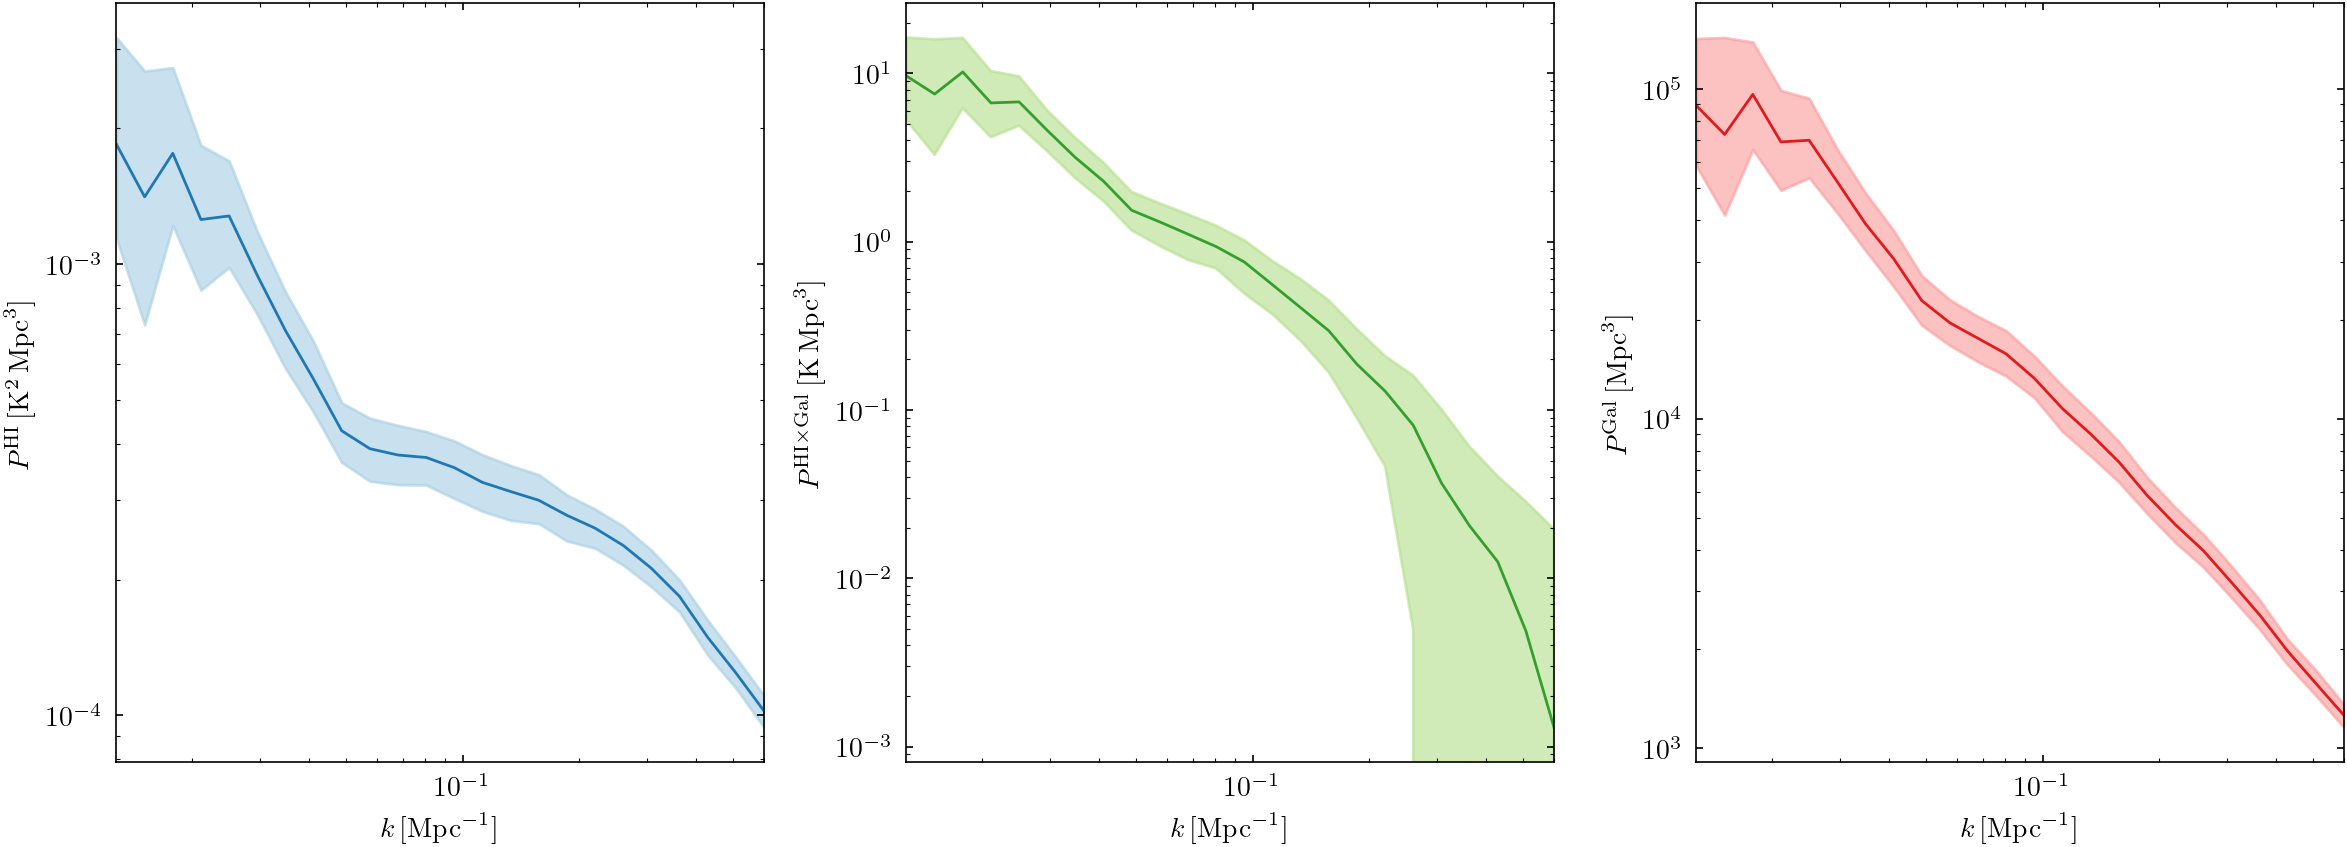

In [14]:
fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(1, 3, figsize=(3.0*fw, 1.5*fh))


color = iter(Cp)

ps = [P_HI_1d_arr, P_HIxGal_1d_arr, P_Gal_1d_arr]
labels = [r"$P^{\rm HI}\,[\mathrm{K}^2\,\mathrm{Mpc}^3]$", r"$P^{\rm HI \times Gal}\,[\mathrm{K}\,\mathrm{Mpc}^3]$", r"$P^{\rm Gal}\,[\mathrm{Mpc}^3]$"]
for ax, p, l in zip(axs.flatten(), ps, labels):
    min, median, max = np.percentile(p, [16, 50, 84], axis=0)
    ax.fill_between(kbc, min, max, color=next(color), alpha=0.6)
    ax.loglog(kbc, median, color=next(color))
    ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(l)

fig.tight_layout()

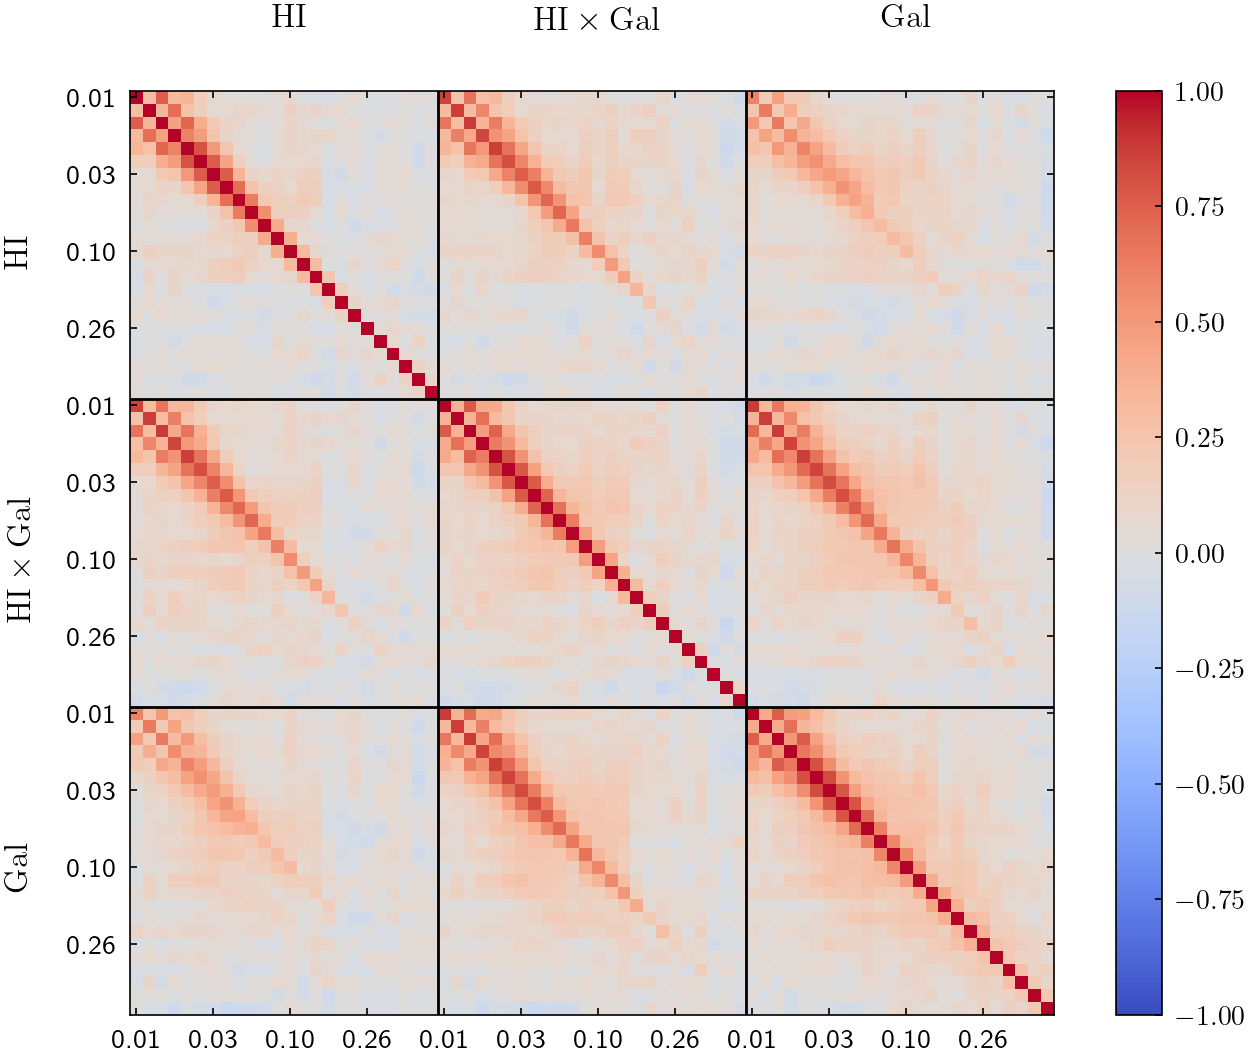

In [15]:
powervector = np.array([*P_HI_1d_arr.T, *P_HIxGal_1d_arr.T, *P_Gal_1d_arr.T]).T
Ns, nk = powervector.shape

cov = 1 / (Ns - 1) * np.einsum("ij, ik->jk", powervector - powervector.mean(0), powervector - powervector.mean(0))
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))

fw, fh = plt.rcParams['figure.figsize'] 

fig, ax = plt.subplots(figsize=(2.0*fw, 2*fh))

im = ax.imshow(corr, vmax=1, vmin=-1, cmap="coolwarm")
plt.colorbar(im, ax=ax)

# boundaries between blocks
n_k = int(nk // 3)
boundaries = [n_k, 2 * n_k]

for b in boundaries:
    ax.axhline(b - 0.5, color='black')
    ax.axvline(b - 0.5, color='black')

# choose a few k indices to label (avoid clutter)
step = np.max((1, n_k // 4))
k_idx = np.arange(0, n_k, step)

# build tick positions across all 3 blocks
xticks = np.concatenate([
    k_idx,
    k_idx + n_k,
    k_idx + 2*n_k
])

xticklabels = np.concatenate([
    [f"{kbc[i]:.2f}" for i in k_idx],
    [f"{kbc[i]:.2f}" for i in k_idx],
    [f"{kbc[i]:.2f}" for i in k_idx]
])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks(xticks)
ax.set_yticklabels(xticklabels)

centers = [n_k/2, 3*n_k/2, 5*n_k/2]

for c, label in zip(centers, [r"$\mathrm{HI}$", r"${\rm HI \times Gal}$", r"$\mathrm{Gal}$"]):
    ax.text(c, -5, label, ha='center', va='bottom', fontsize=12)
    ax.text(-8, c, label, ha='right', va='center', fontsize=12, rotation=90)

plt.savefig("plots/correlation_matrix_3tracers.png")